**Навигация по уроку**

1. [Введение в сверточные нейронные сети](https://colab.research.google.com/drive/10cBnEfHhZlv3ZhEgVimA3GqSEZtvqpTv)
2. [Обучение сверточной нейронной сети на ограниченном наборе данных](https://colab.research.google.com/drive/1e1aZ9K1vQIujPf1mzmta5xtbfNqJ_ai-)
3. [Предобученные сверточные НС](https://colab.research.google.com/drive/12VehrJe062P9QImtvjILQG0DOLooiyk0)
4. Домашняя работа

В данном домашнем задании вам необходимо:

1. Используйте датасет "Собаки и кошки", рассмотренный в данном уроке. Причем используйте его целиком, а не только 4000 изображений.
2. Проведите аугментацию изображений.
3. В качестве предобученной модели возьмите `MobileNet`
4. Создайте модель, приведенную ниже.
5. Обучите модель и проверьте на тестовой выборке.
6. Если модель не обеспечивает заданную точность - "поиграйтесь" с гиперпараметрами.


Для получения 3 баллов за задание необходимо достичь на контрольной выборке точности 90%, 4 баллов -  более 93%, 5 баллов - более 95%.

На 20 тыс. изображений данная модель выдавала нам результат 99%.

**Подсказка**. Обратите внимание, что предлагаемая модель уже не является бинарной классификацией. Это уже задача многоклассовой классификации (в нашем случае 2 класса). А значит в генераторах изображений необходимо использовать:

```pyton
class_mode='categorical'
```

Также необходимо вспомнить какую функцию ошибки использовать с задачей многоклассовой классификации. Можно попробовать в качестве оптимизатора использовать Adam с разными шагами.

Также обратите внимание, что вместо слоя `Flatten()`, вам предлагается использовать `GlobalAveragePooling2D()` (https://keras.io/api/layers/pooling_layers/global_average_pooling2d/).


In [ ]:
import os
import shutil
import zipfile
import random
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNet
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout, Input, BatchNormalization
from tensorflow.keras import optimizers, regularizers
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.metrics import CategoricalAccuracy
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
def load_and_prepare_data():
    # Загрузка датасета
    !wget https://storage.yandexcloud.net/academy.ai/cat-and-dog.zip

    # Разархивируем датасета во временную папку 'temp'
    with zipfile.ZipFile("cat-and-dog.zip", 'r') as zip_ref:
        zip_ref.extractall("./temp")

    # Папка с папками картинок, рассортированных по категориям
    IMAGE_PATH = './temp/training_set/training_set/'

    # Папка в которой будем создавать выборки
    BASE_DIR = './dataset/'

    # Определение списка имен классов
    CLASS_LIST = sorted(os.listdir(IMAGE_PATH))

    # Определение количества классов
    CLASS_COUNT = len(CLASS_LIST)

    # Проверка результата
    print(f'Количество классов: {CLASS_COUNT}, метки классов: {CLASS_LIST}')

    data_files = []  # Cписок путей к файлам изображений
    data_labels = [] # Список меток классов

    for class_label in range(CLASS_COUNT):    # Перебор по всем классам по порядку номеров (их меток)
        class_name = CLASS_LIST[class_label]  # Выборка имени класса из списка имен
        class_path = os.path.join(IMAGE_PATH, class_name)  # Полный путь к папке с изображениями класса

        # Получение списка имен файлов с изображениями текущего класса
        class_files = os.listdir(class_path)

        # Вывод информации о численности класса
        print(f'Размер класса {class_name} составляет {len(class_files)} животных')

        # Добавление к общему списку всех файлов класса с добавлением родительского пути
        data_files += [os.path.join(class_path, file_name) for file_name in class_files]

        # Добавление к общему списку меток текущего класса - их ровно столько, сколько файлов в классе
        data_labels += [class_label] * len(class_files)

    print('Общий размер базы для обучения:', len(data_labels))
    return IMAGE_PATH, BASE_DIR, CLASS_LIST, CLASS_COUNT

In [ ]:
def create_directories(BASE_DIR):
    # При повторном запуске пересоздаим структуру каталогов
    # Если папка существует, то удаляем ее со всеми вложенными каталогами и файлами
    if os.path.exists(BASE_DIR):
        shutil.rmtree(BASE_DIR)

    # Создаем папку по пути BASE_DIR
    os.mkdir(BASE_DIR)

    # Сцепляем путь до папки с именем вложенной папки. Аналогично BASE_DIR + 'train'
    train_dir = os.path.join(BASE_DIR, 'train')

    # Создаем подпапку, используя путь
    os.mkdir(train_dir)

    # Сцепляем путь до папки с именем вложенной папки. Аналогично BASE_DIR + 'validation'
    validation_dir = os.path.join(BASE_DIR, 'validation')

    # Создаем подпапку, используя путь
    os.mkdir(validation_dir)

    # Сцепляем путь до папки с именем вложенной папки. Аналогично BASE_DIR + 'test'
    test_dir = os.path.join(BASE_DIR, 'test')

    # Создаем подпапку, используя путь
    os.mkdir(test_dir)

    return train_dir, validation_dir, test_dir

In [ ]:
def create_dataset(
    img_path: str,
    new_path: str,
    class_name: str,
    start_index: int,
    end_index: int
):
    src_path = os.path.join(img_path, class_name)
    dst_path = os.path.join(new_path, class_name)

    class_files = os.listdir(src_path)
    os.makedirs(dst_path, exist_ok=True)

    for fname in class_files[start_index : end_index]:

        src = os.path.join(src_path, fname)

        dst = os.path.join(dst_path, fname)

        shutil.copyfile(src, dst)

In [ ]:
def split_data(IMAGE_PATH, train_dir, validation_dir, test_dir, CLASS_LIST, CLASS_COUNT):
    TRAIN_SIZE = 0.7
    VALIDATION_SIZE = 0.15
    TEST_SIZE = 0.15

    for class_label in range(CLASS_COUNT):
        class_name = CLASS_LIST[class_label]
        class_path = os.path.join(IMAGE_PATH, class_name)
        class_files = os.listdir(class_path)
        random.shuffle(class_files)

        class_size = len(class_files)
        train_end = int(class_size * TRAIN_SIZE)
        validation_end = int(class_size * (TRAIN_SIZE + VALIDATION_SIZE))

        create_dataset(IMAGE_PATH, train_dir, class_name, 0, train_end)
        create_dataset(IMAGE_PATH, validation_dir, class_name, train_end, validation_end)
        create_dataset(IMAGE_PATH, test_dir, class_name, validation_end, class_size)

In [ ]:
def create_data_generators(train_dir, validation_dir, test_dir, CLASS_COUNT):
    # Аугментация данных только для обучающей выборки
    datagen = ImageDataGenerator(
        rescale=1./255,
        rotation_range=40,
        width_shift_range=0.2,
        height_shift_range=0.2,
        shear_range=0.2,
        zoom_range=0.2,
        horizontal_flip=True,
        fill_mode='nearest'
    )

    # Задание параметров изображений и количества классов
    IMG_WIDTH = 150
    IMG_HEIGHT = 150
    NUM_CLASSES = CLASS_COUNT

    # Генератор для загрузки изображений из папки
    train_generator = datagen.flow_from_directory(
        train_dir,
        target_size=(IMG_WIDTH, IMG_HEIGHT),
        batch_size=32,
        class_mode='categorical'
    )

    validation_datagen = ImageDataGenerator(rescale=1./255)
    test_datagen = ImageDataGenerator(rescale=1./255)

    validation_generator = validation_datagen.flow_from_directory(
        validation_dir,
        target_size=(IMG_WIDTH, IMG_HEIGHT),
        batch_size=32,
        class_mode='categorical'
    )

    test_generator = test_datagen.flow_from_directory(
        test_dir,
        target_size=(IMG_WIDTH, IMG_HEIGHT),
        batch_size=32,
        class_mode='categorical'
    )
    return train_generator, validation_generator, test_generator, IMG_WIDTH, IMG_HEIGHT, NUM_CLASSES

In [ ]:
def create_and_compile_model(IMG_WIDTH, IMG_HEIGHT, NUM_CLASSES):
    def model_maker():
        base_model = MobileNet(include_top=False, input_shape=(IMG_WIDTH, IMG_HEIGHT, 3), weights='imagenet')

        for layer in base_model.layers[:-10]:
            layer.trainable = False

        input = Input(shape=(IMG_WIDTH, IMG_HEIGHT, 3))
        custom_model = base_model(input)
        custom_model = GlobalAveragePooling2D()(custom_model)
        custom_model = Dense(64, activation='relu', kernel_regularizer=regularizers.l2(0.001))(custom_model)
        custom_model = BatchNormalization()(custom_model)
        custom_model = Dropout(0.5)(custom_model)
        predictions = Dense(NUM_CLASSES, activation='softmax')(custom_model)

        return Model(inputs=input, outputs=predictions)

    model = model_maker()
    model.compile(
        optimizer=optimizers.Adam(learning_rate=0.0001),
        loss='categorical_crossentropy',
        metrics=[CategoricalAccuracy()]
    )
    return model

In [ ]:
def train_model(model, train_generator, validation_generator):
    epochs = 20
    history = model.fit(
        train_generator,
        steps_per_epoch=train_generator.samples // train_generator.batch_size,
        epochs=epochs,
        validation_data=validation_generator,
        validation_steps=validation_generator.samples // validation_generator.batch_size,
        callbacks=[EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)]
    )
    test_loss, test_accuracy = model.evaluate(test_generator, steps=test_generator.samples // test_generator.batch_size)
    print(f'Точность на тестовых данных: {test_accuracy * 100:.2f}%')

    return history

--2025-01-19 14:38:41--  https://storage.yandexcloud.net/academy.ai/cat-and-dog.zip
Resolving storage.yandexcloud.net (storage.yandexcloud.net)... 213.180.193.243, 2a02:6b8::1d9
Connecting to storage.yandexcloud.net (storage.yandexcloud.net)|213.180.193.243|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 228082266 (218M) [application/x-zip-compressed]
Saving to: ‘cat-and-dog.zip.23’

cat-and-dog.zip.23  100%[===================>] 217.52M  10.4MB/s    in 20s     

2025-01-19 14:39:02 (10.9 MB/s) - ‘cat-and-dog.zip.23’ saved [228082266/228082266]

Количество классов: 2, метки классов: ['cats', 'dogs']
Размер класса cats составляет 4000 животных
Размер класса dogs составляет 4005 животных
Общий размер базы для обучения: 8005
Found 5603 images belonging to 2 classes.
Found 1201 images belonging to 2 classes.
Found 1201 images belonging to 2 classes.


<ipython-input-7-01f2c15a0756>:3: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNet(include_top=False, input_shape=(IMG_WIDTH, IMG_HEIGHT, 3), weights='imagenet')  # weights='imagenet'


Epoch 1/20


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:122: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


175/175 ━━━━━━━━━━━━━━━━━━━━ 54s 243ms/step - categorical_accuracy: 0.7925 - loss: 0.6057 - val_categorical_accuracy: 0.9510 - val_loss: 0.2289
Epoch 2/20
  1/175 ━━━━━━━━━━━━━━━━━━━━ 4s 24ms/step - categorical_accuracy: 0.8750 - loss: 0.4130

/usr/lib/python3.11/contextlib.py:158: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self.gen.throw(typ, value, traceback)


175/175 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - categorical_accuracy: 0.8750 - loss: 0.4130 - val_categorical_accuracy: 0.9412 - val_loss: 0.2139
Epoch 3/20
175/175 ━━━━━━━━━━━━━━━━━━━━ 38s 208ms/step - categorical_accuracy: 0.9158 - loss: 0.3202 - val_categorical_accuracy: 0.9611 - val_loss: 0.2065
Epoch 4/20
175/175 ━━━━━━━━━━━━━━━━━━━━ 0s 448us/step - categorical_accuracy: 0.9062 - loss: 0.4041 - val_categorical_accuracy: 1.0000 - val_loss: 0.1262
Epoch 5/20
175/175 ━━━━━━━━━━━━━━━━━━━━ 41s 205ms/step - categorical_accuracy: 0.9225 - loss: 0.3020 - val_categorical_accuracy: 0.9679 - val_loss: 0.1848
Epoch 6/20
175/175 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - categorical_accuracy: 1.0000 - loss: 0.1653 - val_categorical_accuracy: 0.9412 - val_loss: 0.3422
Epoch 7/20
175/175 ━━━━━━━━━━━━━━━━━━━━ 37s 207ms/step - categorical_accuracy: 0.9319 - loss: 0.2879 - val_categorical_accuracy: 0.9704 - val_loss: 0.1870
Epoch 8/20
175/175 ━━━━━━━━━━━━━━━━━━━━ 0s 162us/step - categorical_accuracy: 0.9375 - 

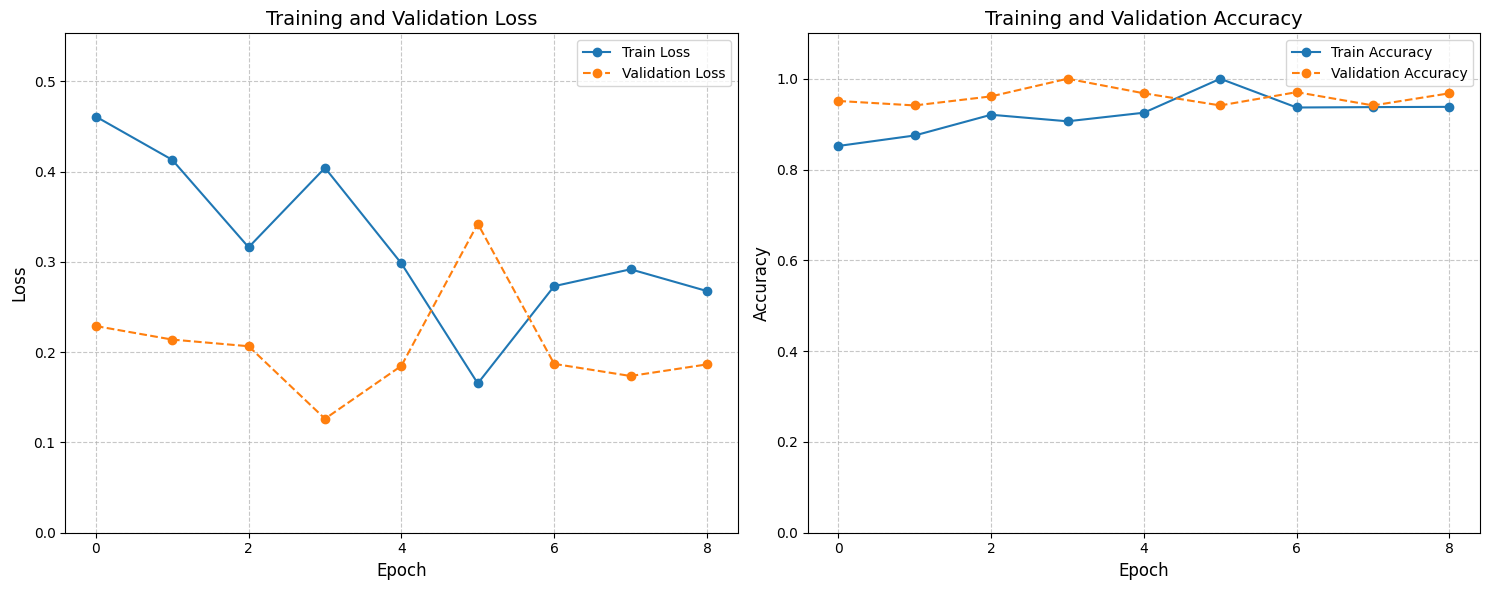

In [ ]:
if __name__ == "__main__":
    IMAGE_PATH, BASE_DIR, CLASS_LIST, CLASS_COUNT = load_and_prepare_data()
    train_dir, validation_dir, test_dir = create_directories(BASE_DIR)
    split_data(IMAGE_PATH, train_dir, validation_dir, test_dir, CLASS_LIST, CLASS_COUNT)
    train_generator, validation_generator, test_generator, IMG_WIDTH, IMG_HEIGHT, NUM_CLASSES = create_data_generators(train_dir, validation_dir, test_dir, CLASS_COUNT)
    model = create_and_compile_model(IMG_WIDTH, IMG_HEIGHT, NUM_CLASSES)
    history = train_model(model, train_generator, validation_generator)

    # Построение графиков потерь и точности
    epochs = len(history.history['loss'])
    plt.figure(figsize=(15, 6))

    # График потерь
    plt.subplot(1, 2, 1)
    plt.plot(history.history['loss'], label='Train Loss', marker='o', linestyle='-')
    plt.plot(history.history['val_loss'], label='Validation Loss', marker='o', linestyle='--')
    plt.title('Training and Validation Loss', fontsize=14)
    plt.xlabel('Epoch', fontsize=12)
    plt.ylabel('Loss', fontsize=12)
    plt.xticks(np.arange(0, epochs, 2))
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.legend(fontsize=10)
    plt.ylim(0, max(max(history.history['loss']), max(history.history['val_loss'])) * 1.2)

    # График точности
    plt.subplot(1, 2, 2)
    plt.plot(history.history['categorical_accuracy'], label='Train Accuracy', marker='o', linestyle='-')
    plt.plot(history.history['val_categorical_accuracy'], label='Validation Accuracy', marker='o', linestyle='--')
    plt.title('Training and Validation Accuracy', fontsize=14)
    plt.xlabel('Epoch', fontsize=12)
    plt.ylabel('Accuracy', fontsize=12)
    plt.xticks(np.arange(0, epochs, 2))
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.legend(fontsize=10)
    plt.ylim(0, 1.1)

    plt.tight_layout()
    plt.show()

In [ ]:
model.save('cats_and_dogs_big_2.h5')